In [4]:
import pandas as pd
from clearml import Task
import numpy as np
import matplotlib.pyplot as plt

import sys
from data import get_dataset
from eval_utils import get_popularity_buckets

from IPython.display import display
import warnings
warnings.filterwarnings('ignore')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  Fi

AttributeError: _ARRAY_API not found

In [5]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=ABP1QYAF3E5FG24SDKULXIR2ESEUNL
%env CLEARML_API_SECRET_KEY=EeLEn8EveqxBKL7oBo1-TnIh2gMXw70D-3_EbH57gdVbMrywzLEcBSx_vAzHe-ul45o

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=ABP1QYAF3E5FG24SDKULXIR2ESEUNL
env: CLEARML_API_SECRET_KEY=EeLEn8EveqxBKL7oBo1-TnIh2gMXw70D-3_EbH57gdVbMrywzLEcBSx_vAzHe-ul45o


In [6]:
"""t = Task.get_task("f257ebe1ce8749e1a5fba54b0c59ff3c")
item_emb = t.artifacts["embeddings_item"].get()
seq_emb = t.artifacts["embeddings_seq"].get()
holdout_ = t.artifacts["holdout_test"].get()"""

't = Task.get_task("f257ebe1ce8749e1a5fba54b0c59ff3c")\nitem_emb = t.artifacts["embeddings_item"].get()\nseq_emb = t.artifacts["embeddings_seq"].get()\nholdout_ = t.artifacts["holdout_test"].get()'

In [7]:
"""task_ids = {
    "BT": "f257ebe1ce8749e1a5fba54b0c59ff3c",
    "FCE": "ba81ff69615046dd867243c47105db2f",
    "SCE": "3b0b07003b7c433ca95139446ccae368",
    #"Dross": "701a0a1733224b69bcfc9f2e527221cd",
    #"gBCE": "7789db0ed37243538cdf85db49a7cb29"
}

item_emb_arr = []
seq_emb_arr = []

for k,v in task_ids.items():
    if v != "":
        task = Task.get_task(v)
        item_emb_arr.append(task.artifacts["embeddings_item"].get())
        seq_emb_arr.append(task.artifacts["embeddings_seq"].get())"""

"""data_description = {
    "items": "itemid",
    "n_items": len(item_emb)
}"""

'data_description = {\n    "items": "itemid",\n    "n_items": len(item_emb)\n}'

In [16]:
d_task_ids = {
    "MovieLens 1M": {
        "BT": "f257ebe1ce8749e1a5fba54b0c59ff3c",
        "FCE": "ba81ff69615046dd867243c47105db2f",
        "SCE": "3b0b07003b7c433ca95139446ccae368",
    },
    "YELP": {
        "BT": "d1787bf27f174ca59ab8975d18bb08f4",
        "FCE": "7a1b8b91e42b4fc1ade15034d79918b6",
        "SCE": "79d31a7ec0524bdca4c0608754319df5"
    },
    "Gowalla": {
        "BT": "7faea67c91fa4d238df04aebcaa9df02",
        "FCE": "85c14515dc2447069e7efb5a94af98ab",
        "SCE": "c98dcaa9fa5646b692df74f814de2cf3"
    }
}

item_emb_arr = {}
seq_emb_arr = {}
d_houldout_ = {}
d_data_description = {}

for dataset, task_ids in d_task_ids.items():
    item_emb_arr[dataset] = []
    seq_emb_arr[dataset] = []
    for k, v in task_ids.items():
        if v != "":
            task = Task.get_task(v)
            it_emb = task.artifacts["embeddings_item"].get()
            item_emb_arr[dataset].append(it_emb)
            seq_emb_arr[dataset].append(task.artifacts["embeddings_seq"].get())
            d_houldout_[dataset] = task.artifacts["holdout_test"].get()
    d_data_description[dataset] = {
        "items": "itemid",
        "n_items": len(it_emb)
    }

2025-04-10 19:07:31,333 - clearml.storage - INFO - Downloading: 25.95MB from https://files.clear.ml/BTSasRec/YELP.%20CE%20Barlow%20twins.d1787bf27f174ca59ab8975d18bb08f4/artifacts/embeddings_item/embeddings_item.npz


███████████████████████████████ 100% | 25.95/25.95 MB [00:25<00:00,  1.02MB/s]: 

2025-04-10 19:07:56,875 - clearml.storage - INFO - Downloaded 25.95 MB successfully from https://files.clear.ml/BTSasRec/YELP.%20CE%20Barlow%20twins.d1787bf27f174ca59ab8975d18bb08f4/artifacts/embeddings_item/embeddings_item.npz , saved to C:/Users/razvor/.clearml/cache/storage_manager/global/0437158bc89eb9d349647dc2155ce8ed.embeddings_item.npz


In [9]:
d_data_paths = {
    "MovieLens 1M": "None",
    "YELP": "data/yelp.csv",
    "Gowalla": "data/gowalla.csv"
}
d_data = {}

for dataset, dpath in d_data_paths.items():
    ds = get_dataset(path=dpath)
    df_train = ds[0]
    pop_buckets = get_popularity_buckets(df_train, ds[1])
    d_data[dataset] = {
        "ds": df_train,
        "pop_buckets": pop_buckets
    }
    

Filtered 64 invalid observations.
Filtered 18808 invalid observations.
Filtered 17810 invalid observations.


In [10]:
def topidx(a, topn):
    parted = np.argpartition(a, -topn)[-topn:]
    return parted[np.argsort(-a[parted])]

def topn_recommendations(scores, topn=10):
    recommendations = np.apply_along_axis(topidx, 1, scores, topn)
    return recommendations



In [28]:
def plot_model_comparison(seq_embeddings_arr, item_embeddings_arr, holdout_, data_description, model_names, ds_name,
                          neg_samples=300, num_users=30, seed=0):
    import numpy as np
    import matplotlib.pyplot as plt
    from numpy.random import RandomState
    from scipy.stats import gaussian_kde

    rng = RandomState(seed)
    holdout_items = holdout_[data_description["items"]].values[:1000]
    M = len(seq_embeddings_arr)
    x_positions = np.linspace(0, M - 1, M)
    fig, ax = plt.subplots(figsize=(6, 6))
    max_width = 0.3  # controls the horizontal width of each density bar

    for m, (seq_emb, item_emb) in enumerate(zip(seq_embeddings_arr, item_embeddings_arr)):
        # Compute scores and select users with the holdout item in top recommendations
        scores = seq_emb @ item_emb.T
        top_recs = topn_recommendations(scores)
        good_users = np.where(top_recs == holdout_items.reshape(-1, 1))[0]
        #print(f"Model {m}: {len(good_users)} good users")
        good_users = np.arange(len(holdout_items))

        # Sample users and extract embeddings for positives and negatives
        users_sample = rng.choice(good_users, min(num_users, len(good_users)), replace=False)
        seq_sample = seq_emb[users_sample]
        pos_sample = item_emb[holdout_items][users_sample]
        n_items = data_description['n_items']
        neg_idx = np.concatenate([
            rng.choice(np.delete(np.arange(n_items), holdout_items[i]), neg_samples, replace=False)
            for i in np.arange(len(holdout_items))[users_sample]
        ])
        neg_sample = item_emb[neg_idx]

        # Aggregate dot product scores (as similarity) for positives and negatives
        pos_scores = np.array([np.dot(pos_sample[i], seq_sample[i])
                               for i in range(len(seq_sample))])
        neg_scores = np.concatenate([
            np.dot(neg_sample[i * neg_samples:(i + 1) * neg_samples], seq_sample[i])
            for i in range(len(seq_sample))
        ])

        #pos_scores = pos_scores / pos_scores.max()
        #neg_scores = neg_scores / neg_scores.max()

        x = x_positions[m]
        # Plot density for negatives (above y=0)
        if neg_scores.size > 1:
            kde_neg = gaussian_kde(neg_scores)
            y_neg = np.linspace(neg_scores.min(), neg_scores.max(), 100)
            dens_neg = kde_neg(y_neg) / kde_neg(y_neg).max() * max_width
            ax.fill_betweenx(y_neg, x - dens_neg, x + dens_neg, color='red', alpha=0.5,
                             label='Negatives' if m == 0 else "")
        # Plot density for positives (mirrored below y=0)
        if pos_scores.size > 1:
            kde_pos = gaussian_kde(pos_scores)
            y_pos = np.linspace(pos_scores.min(), pos_scores.max(), 100)
            dens_pos = kde_pos(y_pos) / kde_pos(y_pos).max() * max_width
            ax.fill_betweenx(y_pos, x - dens_pos, x + dens_pos, color='blue', alpha=0.5,
                             label='Positives' if m == 0 else "")
        # Mark the user (baseline at y=0)
        ax.scatter(x, 0, color='green', marker='x', s=100, label='User' if m == 0 else "")

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel("Models")
    ax.set_ylabel("Item dot product")
    ax.set_title(f"{ds_name}. Density Plot of Scores")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(model_names)
    ax.legend()
    #plt.show()
    return ax



In [12]:
#plot_model_comparison(seq_emb_arr, item_emb_arr, holdout_, data_description, model_names=task_ids.keys(), neg_samples=1000)

Filtered 64 invalid observations.


In [9]:
"""mla = get_dataset(path='None')
df_ml = mla[0]
ml_pb = get_popularity_buckets(df_ml, mla[1])"""

"mla = get_dataset(path='None')\ndf_ml = mla[0]\nml_pb = get_popularity_buckets(df_ml, mla[1])"

In [13]:
def get_buckets_emb_norm(item_emb, pop_buckets):
    ml_emb = np.linalg.norm(item_emb, axis=1)
    ml_norm = pd.DataFrame({
        "itemid": np.arange(len(item_emb)),
        "norm": np.linalg.norm(item_emb, axis=1)
    })
    ml_norm["bucket"] = ml_norm["itemid"].map(pop_buckets)
    bn = ml_norm.groupby("bucket")["norm"].mean()
    bn = bn / bn.max()
    return bn

def plot_norm_bars(bns, names, ds_name):
    metric_names = ["1", "2", "3"]
    models = names
    x = np.arange(len(metric_names))  # the label locations
    k = len(models)
    width = 0.4 / k  # width for each bar

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, model in enumerate(models):
        ax.bar(x + i * width, bns[i].values, width, label=model, alpha = 0.7)

    # Formatting the plot
    ax.set_xlabel('Buckets')
    ax.set_ylabel('Item emebddings norm')
    ax.set_xticks(x + width * (k - 1) / 2)
    ax.set_xticklabels(metric_names)
    ax.legend(loc='lower left')
    ax.set_title(f"{ds_name}. Popularity buckets item emebedding norms")

In [41]:
#get_buckets_emb_norm(item_emb_arr[0])

In [42]:
#get_buckets_emb_norm(item_emb_arr[1])

In [43]:
#get_buckets_emb_norm(item_emb_arr[2])

In [45]:
"""plot_norm_bars([
    get_buckets_emb_norm(item_emb_arr[i])
    for i in range(len(item_emb_arr))
], names=list(task_ids.keys())[:3])"""

'plot_norm_bars([\n    get_buckets_emb_norm(item_emb_arr[i])\n    for i in range(len(item_emb_arr))\n], names=list(task_ids.keys())[:3])'

5

In [ ]:
## Multiple datasets

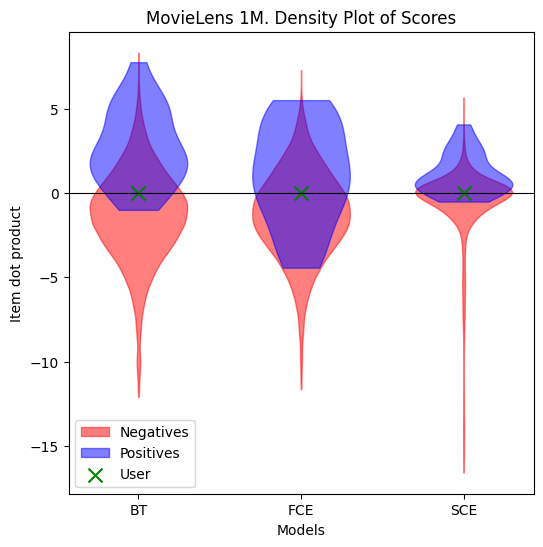

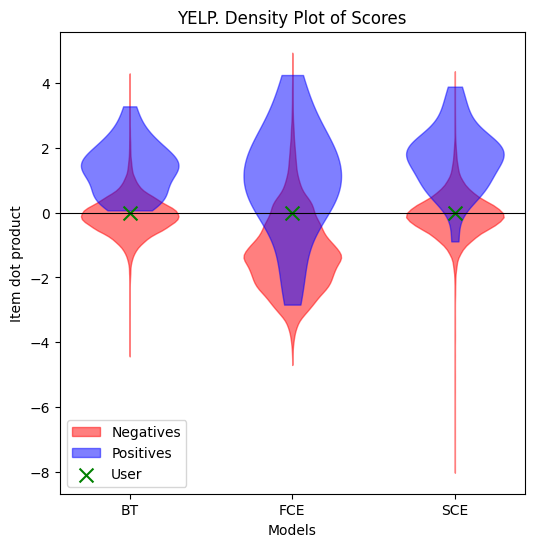

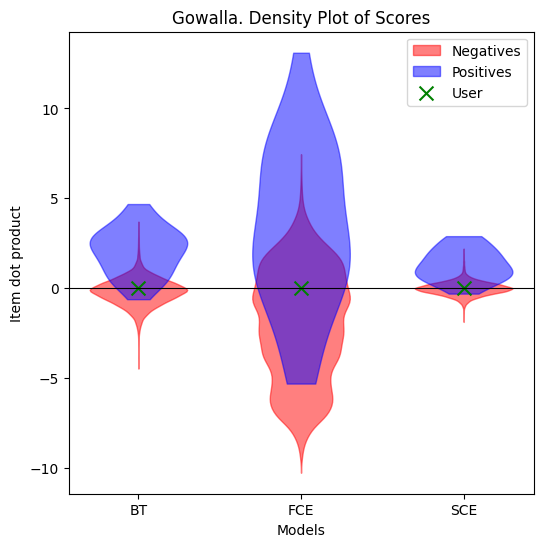

In [ ]:
for dataset, item_emb_arr_i in item_emb_arr.items():
    plot_model_comparison(
        seq_emb_arr[dataset], 
        item_emb_arr[dataset], 
        d_houldout_[dataset], 
        d_data_description[dataset], 
        model_names=d_task_ids[dataset].keys(),
        ds_name=dataset,
        neg_samples=1000
    )
    plt.savefig(f"./plots/scores_density/{dataset}.png")

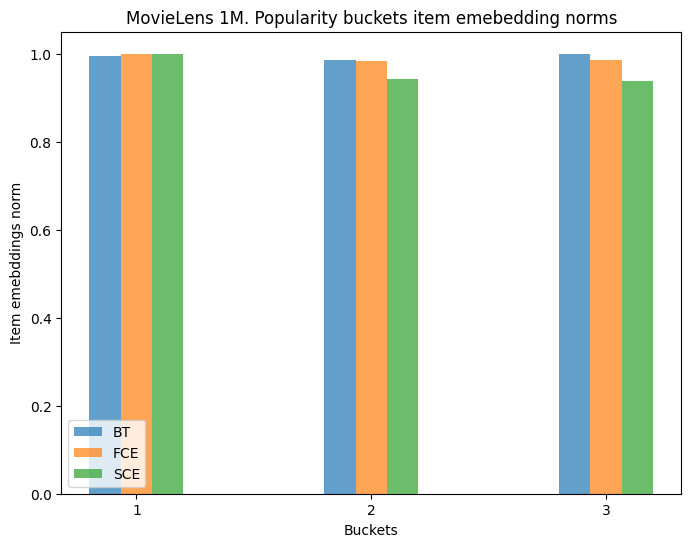

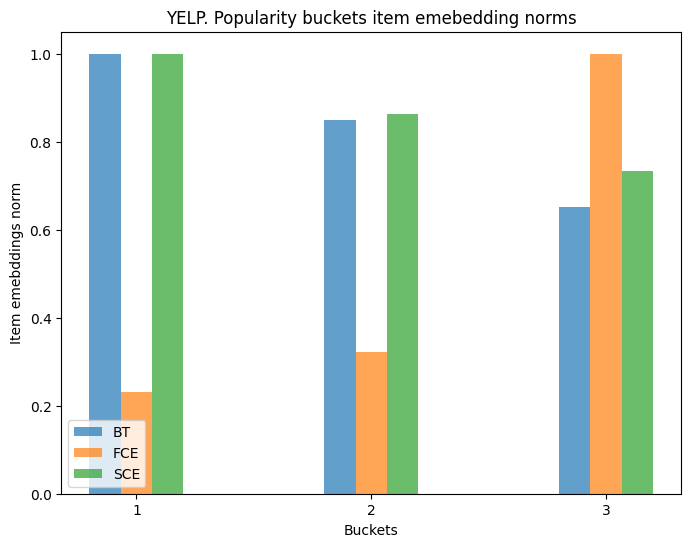

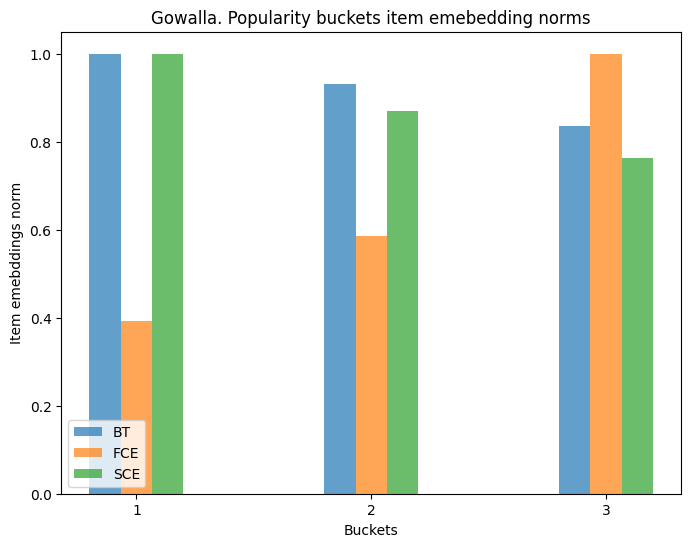

In [18]:
for dataset, item_emb_arr_i in item_emb_arr.items():
    plot_norm_bars([
        get_buckets_emb_norm(
            item_emb_arr[dataset][i], 
            pop_buckets = d_data[dataset]["pop_buckets"]
        )
        for i in range(len(item_emb_arr[dataset]))
    ], names=list(d_task_ids[dataset].keys()), ds_name=dataset)